In [1]:
import math
import warnings

# from Archive.model.quat_utils.Qops_with_QSN import Residual_SA
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from einops import rearrange


In [2]:
from numpy import dtype

inv_sqrt_2 = 1.0 / math.sqrt(2.0)
half = 0.5
eps= 1e-8

# Your original 24 cubic symmetry quaternions
fcc_syms = torch.tensor(
    [
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1],
        [inv_sqrt_2, inv_sqrt_2, 0, 0],
        [inv_sqrt_2, 0, inv_sqrt_2, 0],
        [inv_sqrt_2, 0, 0, inv_sqrt_2],
        [inv_sqrt_2, -inv_sqrt_2, 0, 0],
        [inv_sqrt_2, 0, -inv_sqrt_2, 0],
        [inv_sqrt_2, 0, 0, -inv_sqrt_2],
        [0, inv_sqrt_2, inv_sqrt_2, 0],
        [0, inv_sqrt_2, 0, inv_sqrt_2],
        [0, 0, inv_sqrt_2, inv_sqrt_2],
        [0, inv_sqrt_2, -inv_sqrt_2, 0],
        [0, 0, inv_sqrt_2, -inv_sqrt_2],
        [0, inv_sqrt_2, 0, -inv_sqrt_2],
        [half, half, half, half],
        [half, -half, -half, half],
        [half, -half, half, -half],
        [half, half, -half, -half],
        [half, half, half, -half],
        [half, half, -half, half],
        [half, -half, half, half],
        [half, -half, -half, -half],
        ])


In [3]:
# Used if quaternion is in vector form
def hamilton_prod(q1,q2):

        # import pdb; pdb.set_trace()

        if (q1.shape[1] > q2.shape[1]): # one of them will have the interpolation parameter t embedded in that dimension
                q_new = torch.zeros(q1.shape, device=q1.device, dtype=q1.dtype)
        else:
                q_new = torch.zeros(q2.shape, device=q2.device, dtype=q2.dtype)

        q_new[...,0] = q1[...,0]*q2[...,0] - q1[...,1]*q2[...,1] - q1[...,2]*q2[...,2] - q1[...,3]*q2[...,3]
        q_new[...,1] = q1[...,0]*q2[...,1] + q1[...,1]*q2[...,0] + q1[...,2]*q2[...,3] - q1[...,3]*q2[...,2]
        q_new[...,2] = q1[...,0]*q2[...,2] - q1[...,1]*q2[...,3] + q1[...,2]*q2[...,0] + q1[...,3]*q2[...,1]
        q_new[...,3] = q1[...,0]*q2[...,3] + q1[...,1]*q2[...,2] - q1[...,2]*q2[...,1] + q1[...,3]*q2[...,0]

        return q_new


In [4]:
def inverse2(q):
    return torch.cat([q[...,:1], -q[...,1:]], dim=-1)

def outer_prod(syms, A, order='left'):
    """
    Apply symmetry group quaternions using LEFT ACTION:
        A_sym[g] = syms[g] ⊗ A[n]
    A:    (N, 4)
    syms: (G, 4)
    Returns: (N, G, 4)
    """
    N = A.shape[0]
    G = syms.shape[0]

    # Expand for broadcasting
    A_exp   = A.unsqueeze(1).expand(N, G, 4).reshape(N*G, 4)      # (N*G, 4)
    syms_exp = syms.unsqueeze(0).expand(N, G, 4).reshape(N*G, 4)  # (N*G, 4)

    # LEFT multiplication:   syms ⊗ A
    prod = hamilton_prod(syms_exp, A_exp)

    return prod.view(N, G, 4)

def misorientation(q1, q2):
    dot = torch.sum(q1 * q2, dim=-1)
    return torch.acos(torch.clamp(dot, -1.0 + 1e-7, 1.0 - 1e-7))



In [5]:

# -------------------------------------------------------------------------
# JIT Compiled Math Helpers (Fuse operations for speed)
# -------------------------------------------------------------------------

@torch.jit.script
def hamilton_prod(q1, q2):
    """
    Computes q1 * q2 efficiently.
    Supports broadcasting if shapes align (e.g., q1(N,1,4) * q2(1,M,4))
    """
    w1, x1, y1, z1 = q1[..., 0], q1[..., 1], q1[..., 2], q1[..., 3]
    w2, x2, y2, z2 = q2[..., 0], q2[..., 1], q2[..., 2], q2[..., 3]

    w = w1 * w2 - x1 * x2 - y1 * y2 - z1 * z2
    x = w1 * x2 + x1 * w2 + y1 * z2 - z1 * y2
    y = w1 * y2 - x1 * z2 + y1 * w2 + z1 * x2
    z = w1 * z2 + x1 * y2 - y1 * x2 + z1 * w2

    return torch.stack([w, x, y, z], dim=-1)

@torch.jit.script
def inverse2(q):
    """Conjugate/Inverse for unit quaternions."""
    return torch.cat([q[..., 0:1], -q[..., 1:]], dim=-1)

@torch.jit.script
def quat_log(q, eps: float = 1e-8):
    q = F.normalize(q, dim=-1)
    w = q[..., 0]
    v = q[..., 1:]
    
    # Clamp w to avoid nan in acos
    theta_half = torch.acos(torch.clamp(w, -1.0 + 1e-7, 1.0 - 1e-7))
    sin_theta_half = torch.sin(theta_half)
    
    small_mask = sin_theta_half.abs() < eps
    
    # Avoid division by zero
    scale = theta_half.unsqueeze(-1) / (sin_theta_half.unsqueeze(-1) + eps)
    out = v * scale
    
    # Handle small angles (limit approaches 0)
    # We can't use in-place ops in JIT easily with masking sometimes, 
    # but strict masking is fine here.
    out = torch.where(small_mask.unsqueeze(-1), torch.zeros_like(out), out)
    return out

@torch.jit.script
def quat_exp(v, eps: float = 1e-8):
    theta_half = torch.norm(v, dim=-1, keepdim=True)
    small_mask = theta_half.abs() < eps

    w = torch.cos(theta_half)
    # Avoid division by zero
    scale = torch.sin(theta_half) / (theta_half + eps)
    xyz = v * scale

    q = torch.cat([w, xyz], dim=-1)
    
    # Identity quaternion for small angles
    identity = torch.tensor([1.0, 0.0, 0.0, 0.0], device=q.device, dtype=q.dtype)
    q = torch.where(small_mask, identity, q)

    return F.normalize(q, dim=-1)

# -------------------------------------------------------------------------
# Main Module
# -------------------------------------------------------------------------

class SlerpUpsample(nn.Module):
    def __init__(self, scale_factor, group_quats):
        """
        scale_factor: int
        group_quats: Tensor (G, 4) of symmetry quaternions
        """
        super().__init__()
        self.scale_factor = int(scale_factor)
        
        # Register symmetries as a buffer (persistent state, not a parameter)
        if not torch.is_tensor(group_quats):
            group_quats = torch.tensor(group_quats)
        self.register_buffer("group_quats", group_quats.float())

    def slerp(self, q1, q2, t, syms):
        """
        Batched Symmetry-aware SLERP.
        q1, q2: (N_total, 4)
        t: (Scale,)
        syms: (G, 4)
        """
        # 1. Correct relative rotation in LOCAL frame: A = q2 * q1^-1
        # This represents the rotation to get from q1 to q2
        A = hamilton_prod(q2, inverse2(q1))

        # 2. Apply symmetries: A_syms = S * A (LEFT ACTION)
        # FIX IS HERE: Swapped inputs to hamilton_prod.
        # syms (1, G, 4) * A (N, 1, 4) -> (N, G, 4)
        A_syms = hamilton_prod(syms.unsqueeze(0), A.unsqueeze(1))

        # 3. Ensure positive w (shortest path on 4D sphere)
        # (N, G, 1) mask
        mask = A_syms[..., 0:1] < 0
        A_syms = torch.where(mask, -A_syms, A_syms)

        # 4. Find symmetry with largest real part (smallest angle)
        # Argmax over the G dimension (dim=1)
        best_w, best_indices = torch.max(A_syms[..., 0], dim=1) # (N,)
        
        # Gather the best quaternion
        idx = best_indices.view(-1, 1, 1).expand(-1, 1, 4)
        q_rel = torch.gather(A_syms, 1, idx).squeeze(1) # (N, 4)

        # 5. Interpolate
        v = quat_log(q_rel) # (N, 3)
        
        # Broadcast t
        K = t.shape[0]
        v_scaled = v.unsqueeze(1) * t.view(1, K, 1) # (N, K, 3)
        
        # Flatten to apply exp
        v_flat = v_scaled.reshape(-1, 3)
        q_interp = quat_exp(v_flat).reshape(q1.shape[0], K, 4)

        # 6. Reconstruct: q(t) = q_interp * q1
        # Apply the interpolated relative rotation to q1
        q3 = hamilton_prod(q_interp, q1.unsqueeze(1))

        return q3
    def forward(self, x):
        """
        x: (B, C, H, W) where C = 4*N
        """
        B, C, H, W = x.shape
        assert C % 4 == 0, "Channels must be divisible by 4"
        
        S = self.scale_factor
        if S == 1:
            return x

        # 1. MASSIVE FLATTENING
        # View as (Batch*NumQuats, 4, H, W) then permute to (TotalInstances, H, W, 4)
        # This removes all Python loops over B and N.
        x_reshaped = x.view(B, C // 4, 4, H, W).permute(0, 1, 3, 4, 2).reshape(-1, H, W, 4).contiguous()
        
        # x_reshaped is now (M, H, W, 4) where M = B * (C/4)
        
        # Pre-calculate interpolation fractions t
        # We exclude the endpoint 1.0 because it is the start of the next pixel
        t = torch.linspace(0, 1 - 1/S, steps=S, device=x.device, dtype=x.dtype)

        # -------------------------------------------------------
        # Pass 1: Horizontal (Upsample Width)
        # Input: (M, H, W, 4) -> Output: (M, H, W*S, 4)
        # -------------------------------------------------------
        if W > 1:
            # Prepare pairs for all rows in all images at once
            # q_left: (M, H, W-1, 4) -> Flatten to (TotalSegments, 4)
            q_left  = x_reshaped[..., :-1, :].reshape(-1, 4)
            q_right = x_reshaped[..., 1:, :].reshape(-1, 4)
            
            # Run SLERP on millions of pixels simultaneously
            # Output: (TotalSegments, S, 4)
            q_h_interp = self.slerp(q_left, q_right, t, self.group_quats)
            
            # Reshape and Organize
            # (M, H, W-1, S, 4) -> (M, H, (W-1)*S, 4)
            q_h_interp = q_h_interp.view(x_reshaped.shape[0], H, (W-1)*S, 4)
            
            # Handle Boundary (Last Column)
            # Replicate last column S times
            q_last_col = x_reshaped[..., -1:, :].expand(-1, -1, S, 4).reshape(x_reshaped.shape[0], H, S, 4)
            
            # Concat
            xs = torch.cat([q_h_interp, q_last_col], dim=2) # (M, H, W*S, 4)
        else:
            # Width is 1, just replicate S times
            xs = x_reshaped.repeat_interleave(S, dim=2)

        # -------------------------------------------------------
        # Pass 2: Vertical (Upsample Height)
        # Input: (M, H, W*S, 4) -> Output: (M, H*S, W*S, 4)
        # -------------------------------------------------------
        M, _, W_new, _ = xs.shape
        
        if H > 1:
            # Transpose to treat Height as the dimension to interpolate
            # (M, H, W_new, 4) -> (M, W_new, H, 4)
            xs_t = xs.transpose(1, 2)
            
            # q_top: (M, W_new, H-1, 4) -> Flatten
            q_top = xs_t[..., :-1, :].reshape(-1, 4)
            q_bot = xs_t[..., 1:, :].reshape(-1, 4)
            
            # SLERP
            q_v_interp = self.slerp(q_top, q_bot, t, self.group_quats)
            
            # Reshape: (M, W_new, (H-1)*S, 4)
            q_v_interp = q_v_interp.view(M, W_new, (H-1)*S, 4)
            
            # Handle Boundary (Last Row)
            q_last_row = xs_t[..., -1:, :].expand(-1, -1, S, 4).reshape(M, W_new, S, 4)
            
            # Concat
            xs_final_t = torch.cat([q_v_interp, q_last_row], dim=2) # (M, W_new, H*S, 4)
            
            # Transpose back: (M, H*S, W_new, 4)
            xs_final = xs_final_t.transpose(1, 2)
        else:
            xs_final = xs.repeat_interleave(S, dim=1)

        # -------------------------------------------------------
        # Restore Dimensions
        # -------------------------------------------------------
        # (M, H*S, W*S, 4) -> (B, N, H*S, W*S, 4) -> (B, N, 4, H*S, W*S) -> (B, C, H*S, W*S)
        output = xs_final.view(B, C // 4, H*S, W*S, 4).permute(0, 1, 4, 2, 3).reshape(B, C, H*S, W*S)
        
        return output

In [6]:
# load the LR and HR quaternion data
lr_quats= np.load("/data/home/umang/Materials/Materials_data_mount/EBSD/IN718_FZ_2D_SR_x4/Open718_QSR_x4/Test/LR_Data/Open718_QSR_x4_test_lr_x_block_0.npy")
hr_quats= np.load("/data/home/umang/Materials/Materials_data_mount/EBSD/IN718_FZ_2D_SR_x4/Open718_QSR_x4/Test/HR_Data/Open718_QSR_x4_test_hr_x_block_0.npy")

In [7]:
lr_quats, hr_quats

(array([[[ 0.9444354 ,  0.9444354 ,  0.9444354 , ...,  0.95176655,
           0.95176655,  0.95304585],
         [ 0.8705932 ,  0.8707139 ,  0.87463623, ...,  0.955316  ,
           0.95304585,  0.95304585],
         [ 0.87608665,  0.87608665,  0.8707139 , ...,  0.95304585,
           0.95304585,  0.95304585],
         ...,
         [ 0.8749725 ,  0.87811077,  0.87747014, ...,  0.9766872 ,
           0.97668713,  0.9778478 ],
         [ 0.87747014,  0.8760866 ,  0.87608665, ...,  0.9766872 ,
           0.97522366,  0.9739905 ],
         [ 0.8953739 ,  0.8953739 ,  0.8953739 , ...,  0.9766872 ,
           0.97522366,  0.97522366]],
 
        [[ 0.0778284 ,  0.0778284 ,  0.0778284 , ..., -0.2541588 ,
          -0.2541588 , -0.2548698 ],
         [ 0.35743916, -0.35884613, -0.35281694, ..., -0.24544422,
          -0.2548698 , -0.25623342],
         [-0.3552967 , -0.3552967 , -0.35884613, ..., -0.2548698 ,
          -0.25623342, -0.25623342],
         ...,
         [ 0.36039275,  0.3596361

In [8]:
# apply Slerp upsampling model on the LR quaternions
scale_factor = 4
group_tensor= np.load("/data/home/umang/Materials/Reynolds-QSR/symmetry_groups/O_group.npy")
group_tensor_inv= np.load("/data/home/umang/Materials/Reynolds-QSR/symmetry_groups/O_group_inv.npy")
model= SlerpUpsample(scale_factor=scale_factor, group_quats=fcc_syms)


In [9]:
sr_quats = model(torch.tensor(lr_quats, dtype=torch.float32).unsqueeze(0)).squeeze(0)

In [10]:
lr_quats.shape, hr_quats.shape, sr_quats.shape

((4, 32, 32), (4, 128, 128), torch.Size([4, 128, 128]))

In [11]:
sr_quats[0,:,0], hr_quats[0,:,0]

(tensor([0.9444, 0.9248, 0.8973, 0.8622, 0.8706, 0.8706, 0.8707, 0.8707, 0.8761,
         0.8748, 0.8734, 0.8721, 0.8707, 0.8721, 0.8734, 0.8748, 0.8761, 0.8748,
         0.8734, 0.8721, 0.8707, 0.8717, 0.8727, 0.8737, 0.8746, 0.8746, 0.8746,
         0.8746, 0.8746, 0.8750, 0.8754, 0.8757, 0.8761, 0.8751, 0.8741, 0.8731,
         0.8722, 0.8729, 0.8736, 0.8743, 0.8750, 0.8746, 0.8742, 0.8738, 0.8775,
         0.8775, 0.8775, 0.8775, 0.8775, 0.8771, 0.8768, 0.8764, 0.8761, 0.8764,
         0.8768, 0.8771, 0.8775, 0.8765, 0.8755, 0.8745, 0.8750, 0.8750, 0.8750,
         0.8750, 0.8750, 0.8747, 0.8745, 0.8742, 0.8740, 0.8734, 0.8727, 0.8721,
         0.8746, 0.8740, 0.8734, 0.8728, 0.8757, 0.8757, 0.8757, 0.8757, 0.8757,
         0.8751, 0.8744, 0.8737, 0.8730, 0.8731, 0.8732, 0.8733, 0.8775, 0.8759,
         0.8744, 0.8728, 0.8748, 0.8748, 0.8748, 0.8748, 0.8748, 0.8746, 0.8744,
         0.8742, 0.8740, 0.8742, 0.8744, 0.8746, 0.8751, 0.8744, 0.8736, 0.8729,
         0.8757, 0.8752, 0.8

In [12]:
### import orix a PyPi library used for handling crystal orientation mapping data
from orix.quaternion import Orientation, OrientationRegion, Rotation, Quaternion

# Elements of symmetry groups are set transformations that leave an object invariant. \
# Symmetry groups are quaternion representations of point groups
# There are (naturally in 3D), 32 crystollographic point groups
# Our EBSD Nickel data exhibits Oh (m3m) cyrstallographic point group symmetry.
from orix.quaternion.symmetry import Oh, O

In [13]:
# Convert tensor quaternion data to numpy and then to orix Orientations
# orix expects quaternions in the last axis (..., 4).
# Current tensor has shape (4, H, W) -> move the component axis to the end.
# Important: pass a numpy.ndarray (not a torch.Tensor) to avoid orix calling
# tensor.transpose(...) (which expects two integer dims and would error if given a list).

# convert torch tensor to numpy first (move to CPU if necessary)
data_sr = sr_quats.cpu().numpy() if isinstance(sr_quats, torch.Tensor) else np.array(sr_quats)
data_hr = hr_quats  # already numpy
data_sr = np.moveaxis(data_sr, 0, -1)  # shape -> (H, W, 4)
data_hr = np.moveaxis(data_hr, 0, -1)  # shape -> (H, W, 4)
print(data_sr.shape, data_hr.shape)

(128, 128, 4) (128, 128, 4)


In [14]:
ori_sr = Orientation(data_sr)
ori_hr = Orientation(data_hr)
shape = ori_sr.shape

ori_sr.symmetry = O
ori_hr.symmetry = O
# ori_sr = ori_sr.map_into_symmetry_reduced_zone()
print(ori_sr.shape, ori_hr.shape)

(128, 128) (128, 128)


In [15]:
# Visualize EBSD data with inverse pole figure in the selected data region
from orix.vector import AxAngle, Vector3d
import matplotlib.pyplot as plt
from orix import plot
# plot.IPFColorKeyTSL(Oh).plot()

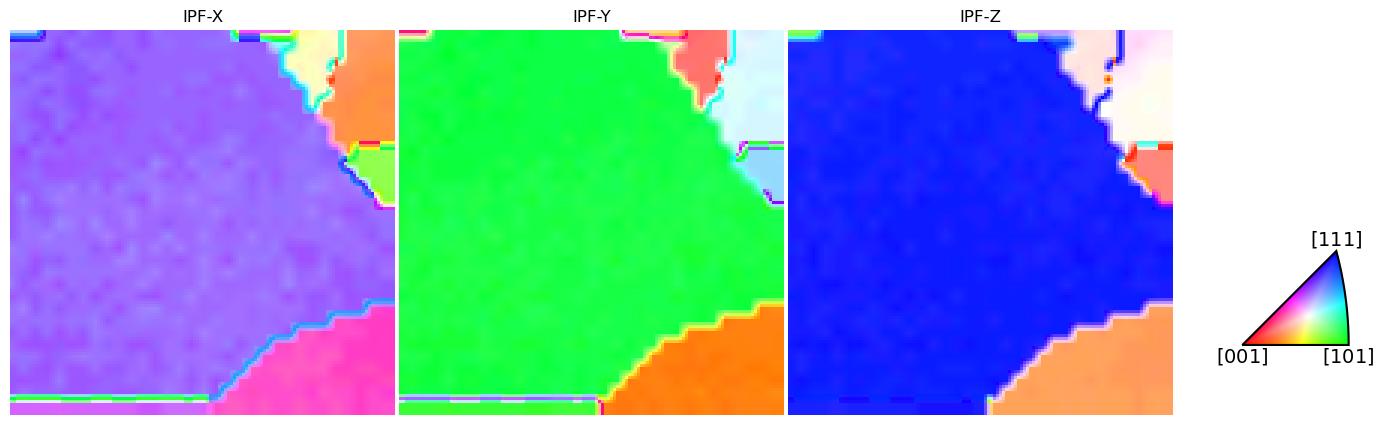

In [16]:
ckey = plot.IPFColorKeyTSL(O)
directions = [(1, 0, 0), (0, 1, 0), (0, 0, 1)]
titles = ["X", "Y", "Z"]

## ALL DATA ##
fig, axes = plt.subplots(ncols=3, figsize=(15, 10))
for i, ax in enumerate(axes):
    ckey.direction = Vector3d(directions[i])
    # Invert because orix assumes lab2crystal when coloring orientations (bc inverse pole figure)
    ax.imshow(ckey.orientation2color(ori_sr))
    ax.set_title(f"IPF-{titles[i]}")
    ax.axis("off")

# Add color key
ax_ipfkey = fig.add_axes(
    [0.932, 0.37, 0.1, 0.1],  # (Left, bottom, width, height)
    projection="ipf",
    symmetry=ori_sr.symmetry.laue,
)
ax_ipfkey.plot_ipf_color_key()
ax_ipfkey.set_title("")
fig.subplots_adjust(wspace=0.01)

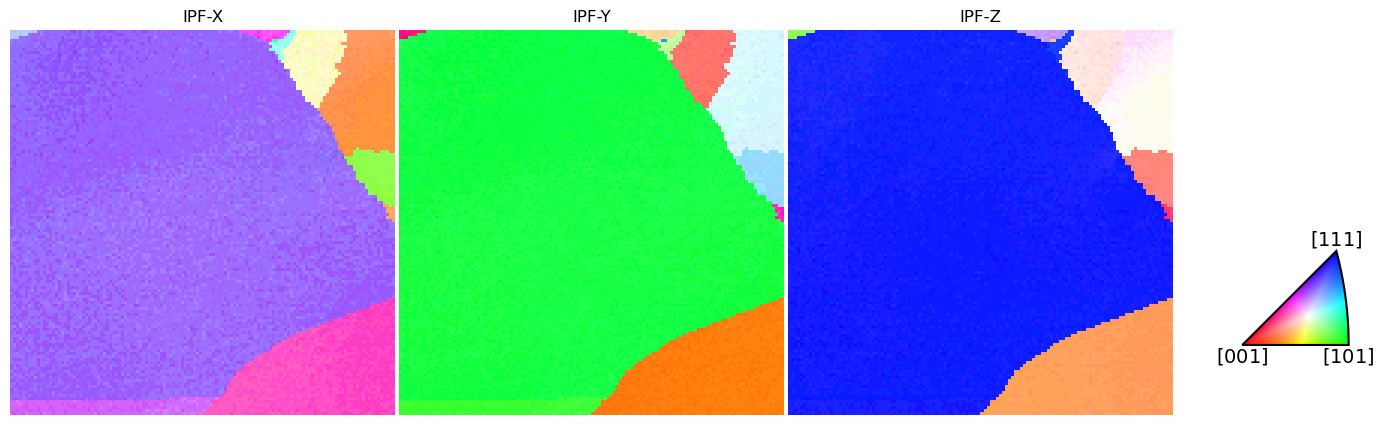

In [17]:
ckey = plot.IPFColorKeyTSL(O)
directions = [(1, 0, 0), (0, 1, 0), (0, 0, 1)]
titles = ["X", "Y", "Z"]

## ALL DATA ##
fig, axes = plt.subplots(ncols=3, figsize=(15, 10))
for i, ax in enumerate(axes):
    ckey.direction = Vector3d(directions[i])
    # Invert because orix assumes lab2crystal when coloring orientations (bc inverse pole figure)
    ax.imshow(ckey.orientation2color(ori_hr))
    ax.set_title(f"IPF-{titles[i]}")
    ax.axis("off")

# Add color key
ax_ipfkey = fig.add_axes(
    [0.932, 0.37, 0.1, 0.1],  # (Left, bottom, width, height)
    projection="ipf",
    symmetry=ori_hr.symmetry.laue,
)
ax_ipfkey.plot_ipf_color_key()
ax_ipfkey.set_title("")
fig.subplots_adjust(wspace=0.01)